In [6]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import pandas as pd


from paths import *
from reshandler import DictResHandler
from misc_tools import PathUtils as PU
from misc_recorder import ListRecorder

# from C_0B_eval import *
# from C_0X_defs import *
from scipy.stats import sem, ttest_ind

In [10]:
train_name = "E_0A"
ts = "1113024340"
model_condition = "b"
res_save_dir = os.path.join(model_save_, f"eval-{train_name}-{ts}")

results = []
for model_type in ['recon16-phi']: # 'recon4-phi', 'recon8-phi', 'recon32-phi'
    for model_condition in ['b']: 
        for run in range(1, 6): 
            res_read_dir = os.path.join(model_save_, f"{train_name}-{ts}-{run}", f"{model_type}", f"{model_condition}")
            valid_recon_losses = ListRecorder(os.path.join(res_read_dir, "valid.recon.loss"))
            valid_recon_losses.read()
            data = valid_recon_losses.get()
            dimension = 0
            if model_type == 'recon4-phi':
                dimension = 4
            elif model_type == 'recon8-phi': 
                dimension = 8
            elif model_type == 'recon16-phi': 
                dimension = 16
            elif model_type == 'recon32-phi': 
                dimension = 32
            datadict = {'dimension': dimension, 'model_condition': model_condition, 'run': run, 'recon_loss': data}
            results.append(datadict)

In [26]:
# Create an empty list to store the transformed data
data = []

# Iterate over each run
for run in results:
    run_id = run['run']
    losses = run['recon_loss']
    
    # Iterate over each epoch and its corresponding loss
    for epoch_num, loss in enumerate(losses, start=1):
        data.append({'run_id': run_id, 'epoch': epoch_num, 'loss': loss})

# Convert the list to a DataFrame
df = pd.DataFrame(data)

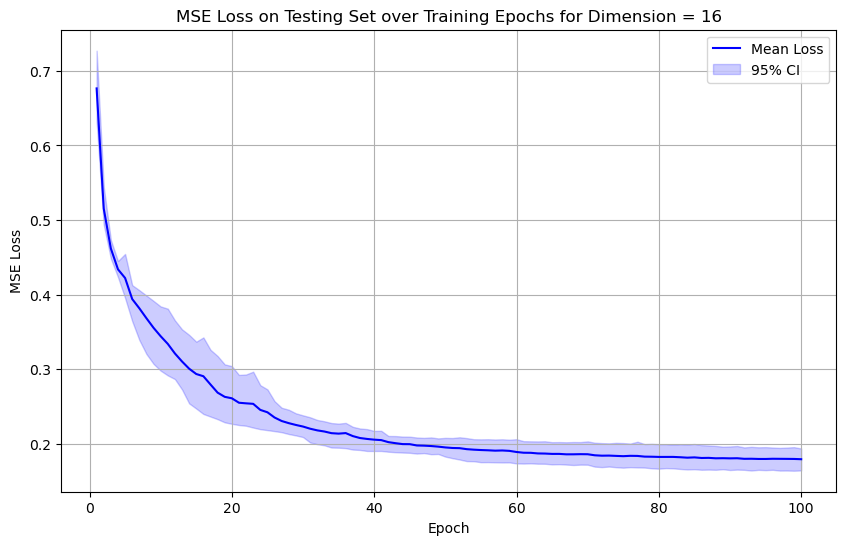

In [48]:
# Calculate mean and confidence interval (95%) for each epoch
from turtle import color

from numpy import var


epoch_stats = df.groupby('epoch')['loss'].agg(
    mean_loss='mean',
    std_loss='std',  # Standard deviation
    ci_lower=lambda x: np.percentile(x, 2.5),  # Lower bound of 95% CI
    ci_upper=lambda x: np.percentile(x, 97.5),   # Upper bound of 95% CI
).reset_index()

# Plot the loss curve
plt.figure(figsize=(10, 6))
plt.plot(epoch_stats['epoch'], epoch_stats['mean_loss'], label='Mean Loss', 
        #  color="#1a80bb", 
        color='blue',)

# Add shaded region for confidence interval
plt.fill_between(
    epoch_stats['epoch'], 
    epoch_stats['ci_lower'], 
    epoch_stats['ci_upper'], 
    # color='#1a80bb', 
    color='blue',
    alpha=0.2, 
    label='95% CI'
)

# Add labels and title
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('MSE Loss on Testing Set over Training Epochs for Dimension = 16')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
epoch_stats.to_csv('epoch_stats.csv', index=False)

In [7]:
# Perform the groupby and calculate the mean for the remaining column
grouped_df = resultsdf.groupby(["dimension", "model_condition"])["recon_loss"].mean().reset_index()

In [8]:
grouped_df

,dimension,model_condition,recon_loss
0,4,b,0.401569
1,4,u,0.369832
2,8,b,0.222804
3,8,u,0.216290
4,16,b,0.125158
5,16,u,0.119112
6,32,b,0.078389
7,32,u,0.075468


In [9]:
gbres = grouped_df[grouped_df['model_condition'] == 'b']
gures = grouped_df[grouped_df['model_condition'] == 'u']

In [20]:
outstr = ""
for dim in [4, 8, 16, 32]: 
    r = gbres[gbres['dimension'] == dim]['recon_loss'].values[0]
    outstr += "\overline{\epsilon}_{%d} = %.4f, " % (dim, r)

In [21]:
print(outstr)

\overline{\epsilon}_{4} = 0.4016, \overline{\epsilon}_{8} = 0.2228, \overline{\epsilon}_{16} = 0.1252, \overline{\epsilon}_{32} = 0.0784, 


In [22]:
outstr = ""
for dim in [4, 8, 16, 32]: 
    r = gures[gures['dimension'] == dim]['recon_loss'].values[0]
    outstr += "\overline{\epsilon}_{%d} = %.4f, " % (dim, r)

In [23]:
print(outstr)

\overline{\epsilon}_{4} = 0.3698, \overline{\epsilon}_{8} = 0.2163, \overline{\epsilon}_{16} = 0.1191, \overline{\epsilon}_{32} = 0.0755, 


In [19]:
bres = resultsdf[resultsdf['model_condition'] == 'b']
ures = resultsdf[resultsdf['model_condition'] == 'u']

In [21]:
bres["recon_loss"].corr(bres["dimension"]), ures["recon_loss"].corr(ures["dimension"])

(-0.8299008887209766, -0.8565714128555049)